Markov Chain Monte Carlo (MCMC) example

Brusselator model

Alexander Johnston Queensland University of Technology a44.johnston@qut.edu.au

In [1]:
using Plots, DelimitedFiles, DifferentialEquations, SparseArrays, Interpolations, Random, Distributions, NLopt, Dierckx, LaTeXStrings, BSplineKit, Plots.PlotMeasures, LinearAlgebra
gr()

plot_font = "Computer Modern"
default(fontfamily=plot_font,linewidth=1,framestyle=:box,label=nothing,grid=true)

#Model parameters

av = 1; #Note that a,b>0
b = 2;
c1_0 = 1; 
c2_0 = 0.5;

a = [av, b];

#Initial conditions 
x0 = c1_0; y0 = c2_0;

ic = [x0, y0];

#Number of synthetic data points 
N_data = 21;

t_start = 0;
t_end = 15;
tt = LinRange(t_start, t_end, N_data);

t = tt;

#Standard deviation of additive Gaussian noise used to generate the synthetic data
sigma = 0.025;


Creating synthetic data sets.

In [3]:
#Create synthetic data for Brussellator model

function Brusselator!(du,u,a,t)
av = a[1];
b = a[2];
du[1]= 1 - (b+1)*u[1] + av*u[1]^2*u[2]; 
du[2]= b*u[1] - av*u[1]^2*u[2];
end

function odesolver(t,ic,a)
tspan=(0.0,maximum(t))
prob=ODEProblem(Brusselator!,ic,tspan, a)
alg=Tsit5()
sol=solve(prob,alg,saveat=t);
return sol
end

ic=[x0, y0]
sol = odesolver(t,ic,a)
x_true = sol[1,:];
y_true = sol[2,:];

#Create stochastic data using additive Gaussian noise applied at each data point for the true solution

dist=Normal(0,sigma);

x_data_sample = zeros(length(x_true));
y_data_sample = zeros(length(y_true));

for (i, x_model_i) in enumerate(x_true)
    x_data_sample[i] = x_model_i + rand(dist)
end

for (i, y_model_i) in enumerate(y_true)
    y_data_sample[i] = y_model_i + rand(dist)
end

t_data = t;

t = tt;

xy_data_sample = vcat(x_data_sample, y_data_sample);

MCMC Procedure

In this section, we set up the hyperparameters for the MCMC algorithm, and then conduct inference with MCMC.

In [4]:
#Hyperparameters
h = 0.01; #Step size in parameter space
N_iter = 100000; #Number of iterations in MCMC trace
b_in = 20000; #Burn-in iterations

In [5]:
#MCMC Procedure
t1 = time();

dist_normal = Normal(0,sigma);

#Initial parameter values
alpha_start = 1.1; 
delta_start = 2.9;

alpha_list = [alpha_start];
delta_list = [delta_start];

alpha_i = alpha_start; 
delta_i = delta_start;

sol = odesolver(tt,ic,[alpha_i,delta_i]);
x_test = sol[1,:];
y_test = sol[2,:];

xy_test = vcat(x_test, y_test);

l_i = loglikelihood(dist_normal, (xy_data_sample - xy_test));

likelihood_list = [l_i];

for i in range(1, N_iter);

    a_i = vcat(alpha_i, delta_i);

    sol = odesolver(tt,ic,[alpha_i,delta_i]);
    x_test = sol[1,:];
    y_test = sol[2,:];

    xy_test = vcat(x_test, y_test);
    l_i = loglikelihood(dist_normal, (xy_data_sample - xy_test));
    
    #Transition point
    phi_1 = rand(Uniform(0, 2*pi));
    phi_2 = rand(Uniform(0, 2*pi));
    alpha_step = h*cos(phi_1);
    delta_step = h*sin(phi_2);
    
    if alpha_i + alpha_step > 0 && delta_i + delta_step > 0
        alpha_i_test = alpha_i + alpha_step
        delta_i_test = delta_i + delta_step;
    else
        alpha_i_test = alpha_i
        delta_i_test = delta_i
    end
        
    a_i_test = vcat(alpha_i_test, delta_i_test);
    sol = odesolver(tt,ic,[alpha_i,delta_i]);
    x_test = sol[1,:];
    y_test = sol[2,:];

    sol = odesolver(tt,ic,[alpha_i_test,delta_i_test]);
    x_test_new = sol[1,:];
    y_test_new = sol[2,:];
    xy_test_new = vcat(x_test_new, y_test_new);

    l_i_test = loglikelihood(dist_normal, (xy_data_sample - xy_test_new));
    
    p_ratio = exp(l_i_test - l_i);
    gamma = min(1, p_ratio);
    transition_accepted = rand(Binomial(1, gamma));
    
    if transition_accepted == 1
        alpha_i = alpha_i_test;
        delta_i = delta_i_test;
    end

    alpha_list = vcat(alpha_list, alpha_i);
    delta_list = vcat(delta_list, delta_i);
    likelihood_list = vcat(likelihood_list, l_i);
end

elapsed_time = time() - t1;
println("Elapsed time: ", elapsed_time, " seconds")

Elapsed time: 15.257061004638672 seconds


We now plot histograms of parameter estimates after the burn-in period.

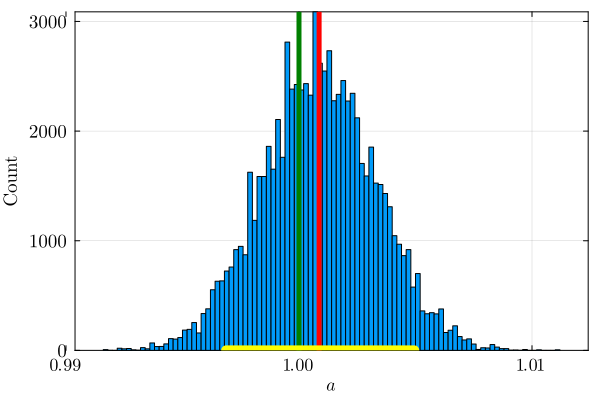

In [6]:
alpha_percentile_05 = quantile(vec(alpha_list), 0.05)
alpha_percentile_95 = quantile(vec(alpha_list), 0.95)

pha = histogram(alpha_list[b_in:N_iter], xlabel=L"a", ylabel = "Count", xticks=([0.99, 1, 1.01],[L"0.99",L"1.00", L"1.01"]), xguidefontsize=12, yguidefontsize=12,xtickfontsize=12, ytickfontsize=12)
pha = vline!([mean(alpha_list[b_in:N_iter])], color = :red, linewidth = 5)
pha = vline!([av], color = :green, linewidth = 5)
pha = plot!([alpha_percentile_05; alpha_percentile_95], [0; 0], lw=10, lc=:yellow, legend=false)

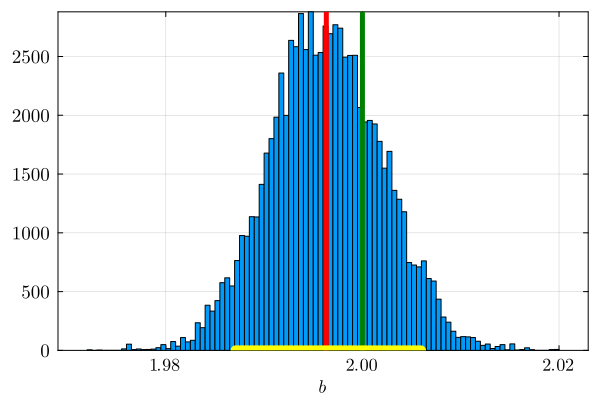

In [7]:
delta_percentile_05 = quantile(vec(delta_list[b_in:N_iter]), 0.05)
delta_percentile_95 = quantile(vec(delta_list[b_in:N_iter]), 0.95)

phd = histogram(delta_list[b_in:N_iter], xlabel=L"b", xticks=([1.98, 2, 2.02],[L"1.98",L"2.00", L"2.02"]), xguidefontsize=12, yguidefontsize=12,xtickfontsize=12, ytickfontsize=12)
phd = vline!([mean(delta_list[b_in:N_iter])], color = :red, linewidth = 5)
phd = vline!([b], color = :green, linewidth = 5)
phd = plot!([delta_percentile_05; delta_percentile_95], [0; 0], lw=10, lc=:yellow, legend=false)

We then produce a contour plot of the parameter estimates after the burn-in period.

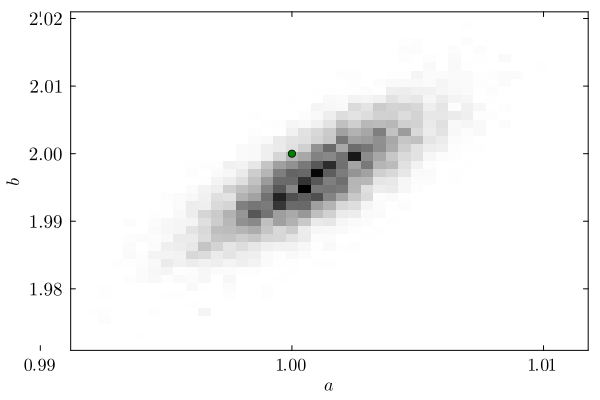

In [8]:
N_alpha = 40;
N_delta = 40;

alpha_min = minimum(alpha_list[b_in:N_iter]);
delta_min = minimum(delta_list[b_in:N_iter]);

alpha_max = maximum(alpha_list[b_in:N_iter]);
delta_max = maximum(delta_list[b_in:N_iter]);

alpha_bins = LinRange(alpha_min, alpha_max, N_alpha);
delta_bins = LinRange(delta_min, delta_max, N_delta);

pc = histogram2d(alpha_list[b_in:N_iter], delta_list[b_in:N_iter], xticks=([0.99, 1, 1.01],[L"0.99",L"1.00", L"1.01"]), grid = false, colorbar = false, c=:binary, bins = (alpha_bins, delta_bins), xlabel=L"a", ylabel=L"b", xguidefontsize=12, yguidefontsize=12,xtickfontsize=12, ytickfontsize=12)
pc = scatter!([av], [b], color = :green)

Final plot containing the MCMC results.

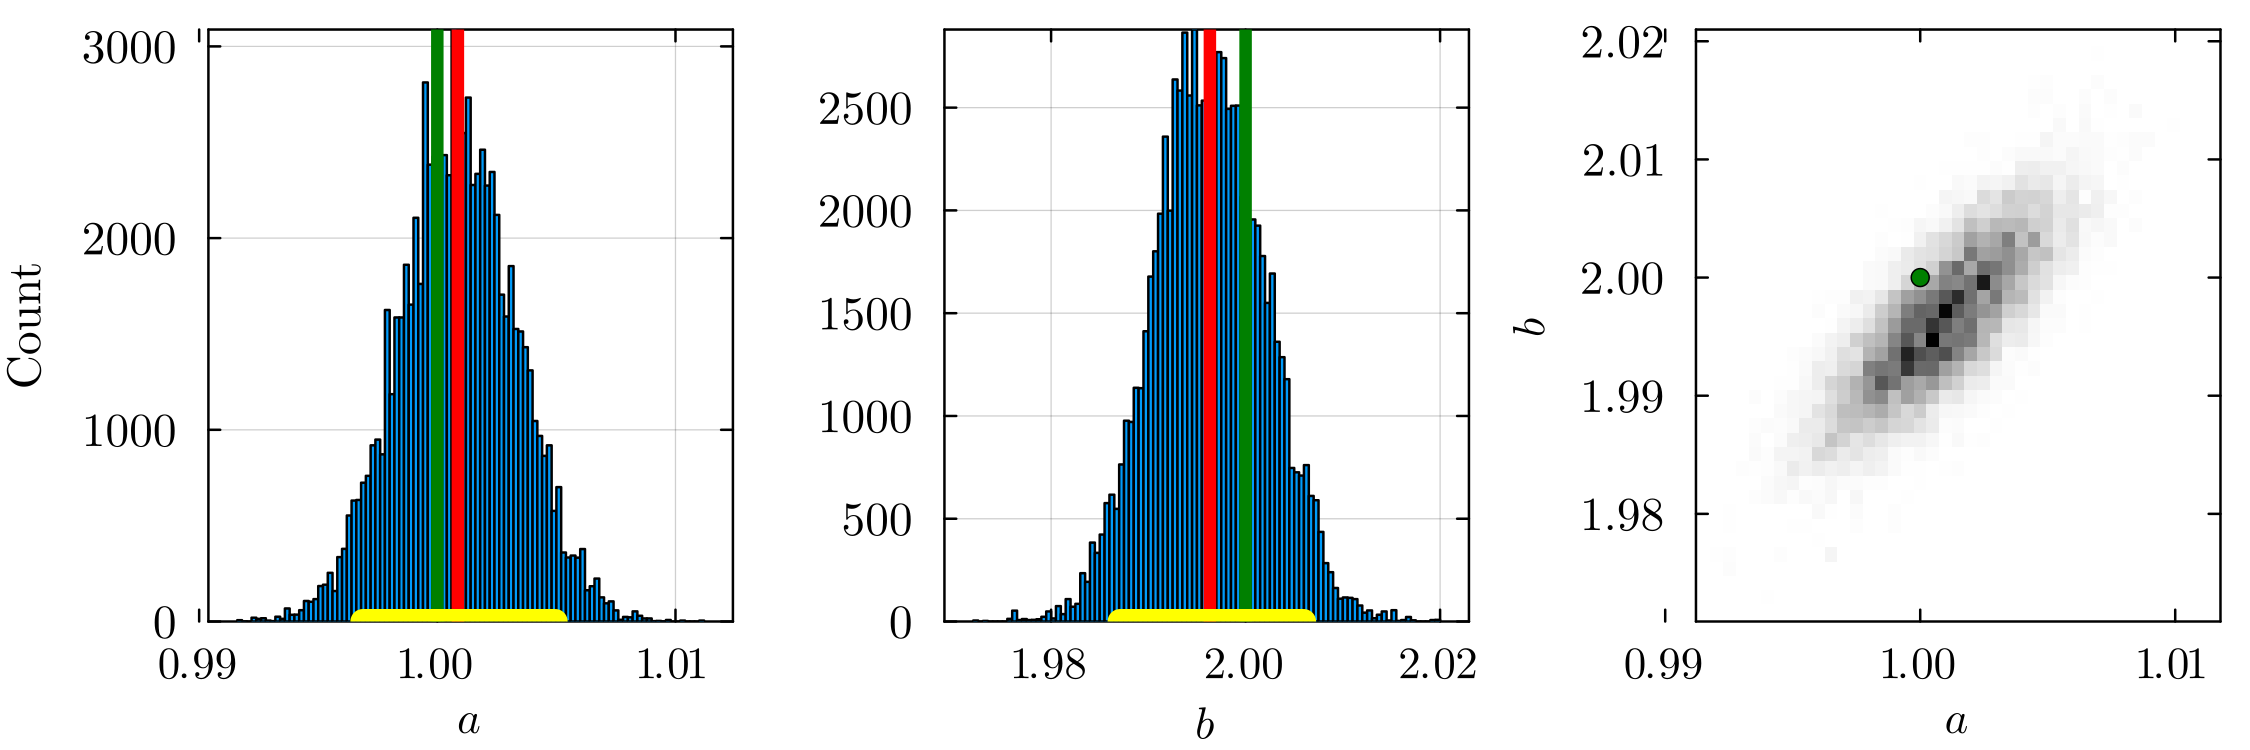

In [9]:
MCMC_plot = plot(pha, phd, pc, layout = grid(1, 3), size = (900, 300), dpi = 250, bottom_margin=5mm, left_margin=4mm)